<a href="https://colab.research.google.com/github/sandhya842/week1-AI-/blob/main/2501608_sandhyaChaudhary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Feature selection
from sklearn.feature_selection import SelectKBest, chi2

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, f1_score


In [29]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/AI/dirty_v3_path.csv")

# Preview data
df.head()


,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,random_notes,noise_col
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,lorem,-137.057211
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,ipsum,-11.230610
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,ipsum,98.331195
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,lorem,44.187175
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,lorem,44.831426


In [30]:
# Dataset structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       300

In [31]:
# Statistical summary of numerical features
df.describe()


,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,noise_col
count,25500.000000,25500.000000,25500.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,54.616784,123.622179,140.455337,28.476155,94.954992,4.414133,213.033891,176.837375,6.294377,0.279767,0.238533,3.803214,4.029654,0.439433,5.917312,6.229836,-0.517010
std,15.973618,41.576943,21.077933,5.728804,3.736202,2.761536,33.519757,48.812827,1.320269,0.448892,0.426194,2.011729,1.817165,0.496326,2.225057,1.187669,100.076959
min,10.000000,20.320000,74.240000,7.670000,67.510000,1.000000,95.730000,-22.480000,3.280000,0.000000,0.000000,-3.680000,-1.750000,0.000000,-2.440000,1.590000,-412.169596
25%,45.000000,96.280000,125.140000,24.590000,93.000000,3.000000,189.500000,141.280000,5.330000,0.000000,0.000000,2.350000,2.770000,0.000000,4.370000,5.410000,-68.270749
50%,55.000000,110.500000,138.320000,28.050000,95.300000,4.000000,211.835000,173.365000,5.970000,0.000000,0.000000,3.590000,3.790000,0.000000,5.900000,6.230000,-0.510742
75%,66.000000,136.610000,153.790000,31.810000,97.380000,5.000000,235.310000,208.630000,6.920000,1.000000,0.000000,5.060000,5.020000,1.000000,7.440000,7.050000,66.811399
max,89.000000,318.510000,226.380000,56.850000,110.070000,19.000000,358.370000,421.510000,12.360000,1.000000,1.000000,12.410000,12.060000,1.000000,15.450000,10.350000,467.894910


In [32]:
df.isnull().sum()


,0
Age,4500
Gender,4500
Medical Condition,4500
Glucose,4500
Blood Pressure,4500
BMI,0
Oxygen Saturation,0
LengthOfStay,0
Cholesterol,0
Triglycerides,0


In [33]:
# Check column names
print(df.columns)
TARGET_COL = 'Medical Condition'


# Drop rows where target is missing
df = df.dropna(subset=[TARGET_COL])

print("Remaining rows:", df.shape[0])


Index(['Age', 'Gender', 'Medical Condition', 'Glucose', 'Blood Pressure',
       'BMI', 'Oxygen Saturation', 'LengthOfStay', 'Cholesterol',
       'Triglycerides', 'HbA1c', 'Smoking', 'Alcohol', 'Physical Activity',
       'Diet Score', 'Family History', 'Stress Level', 'Sleep Hours',
       'random_notes', 'noise_col'],
      dtype='object')
Remaining rows: 25500


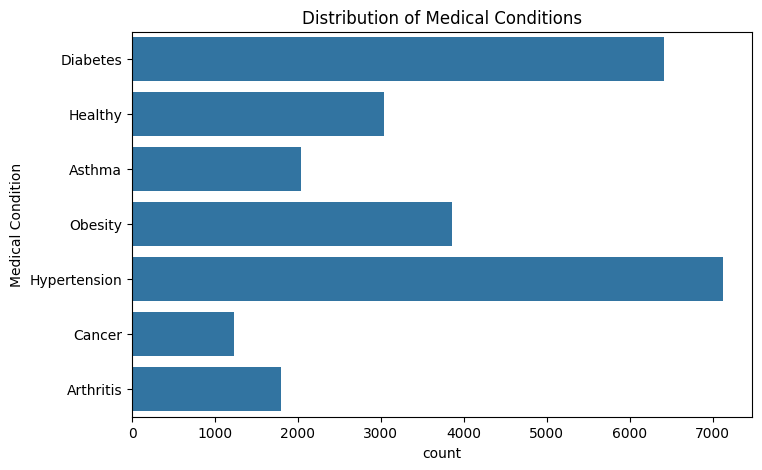

In [34]:
#EDA-target distribution
plt.figure(figsize=(8,5))
sns.countplot(y='Medical Condition', data=df)
plt.title("Distribution of Medical Conditions")
plt.show()



Insight:
The target distribution shows class imbalance, where some medical conditions
occur much more frequently than others. This imbalance suggests that accuracy
alone is not sufficient for evaluation, and metrics such as F1-score and recall
should be considered.


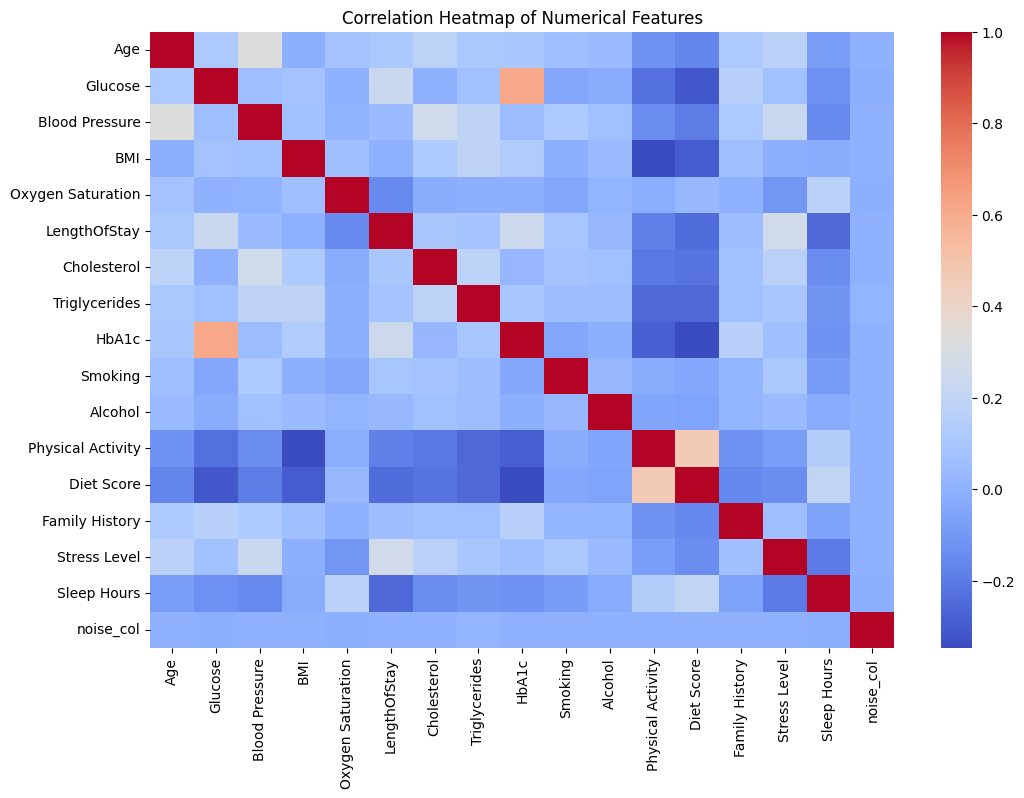

In [35]:
#EDA-correlation-Heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


Insight:
The correlation heatmap shows the strength of relationships between numerical
health indicators. Strong positive correlations are observed between clinically
related variables such as glucose and HbA1c, and between BMI, cholesterol, and
triglycerides.

These relationships indicate that certain health measurements tend to increase
together, reflecting underlying physiological connections. Identifying such
correlations helps in feature selection and prevents redundancy in machine
learning models.


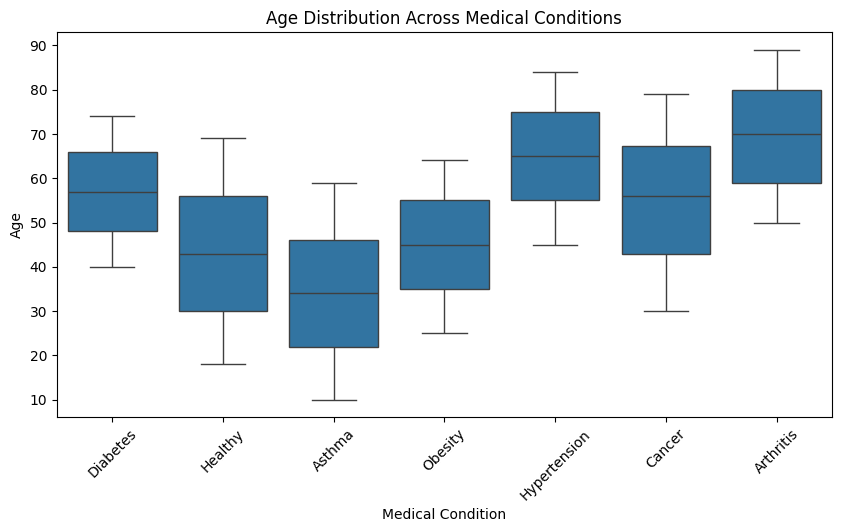

In [36]:
#EDA-BoxPlot - age
plt.figure(figsize=(10,5))
sns.boxplot(x='Medical Condition', y='Age', data=df)
plt.xticks(rotation=45)
plt.title("Age Distribution Across Medical Conditions")
plt.show()


Insight:
The age boxplot reveals the presence of outliers and a wide age range among
patients. Older age groups show higher variability, which may contribute to
increased health risks and must be considered during modeling.

In [37]:
#feature target split
# Separate feature columns
X = df.drop(columns=['Medical Condition', 'random_notes', 'noise_col'])
y = df['Medical Condition']

#handle missing values
# Identify column types
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include='object').columns

# Impute numeric features
num_imputer = SimpleImputer(strategy='median')
X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])

# Impute categorical features
cat_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])


In [38]:
# One-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X.head()


,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,Gender_Male
0,46.0,137.04,135.270,28.90,96.04,6.0,231.88,210.56,7.61,0.0,0.0,-0.20,3.54,0.0,5.07,6.05,True
1,22.0,71.58,113.270,26.29,97.54,2.0,165.57,129.41,4.91,0.0,0.0,8.12,5.90,0.0,5.87,7.72,True
2,50.0,95.24,138.285,22.53,90.31,2.0,214.94,165.35,5.60,0.0,0.0,5.01,4.65,1.0,3.09,4.82,False
3,57.0,110.51,130.530,38.47,96.60,5.0,197.71,182.13,6.92,0.0,0.0,3.16,3.37,0.0,3.01,5.33,False
4,66.0,95.15,178.170,31.12,94.90,4.0,259.53,115.85,5.98,0.0,1.0,3.56,3.40,0.0,6.38,6.64,False


In [39]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Target Classes:", le.classes_)


Target Classes: ['Arthritis' 'Asthma' 'Cancer' 'Diabetes' 'Healthy' 'Hypertension'
 'Obesity']


In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [41]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [42]:
#Logistic regression
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred, target_names=le.classes_))


Logistic Regression Accuracy: 0.9047058823529411
              precision    recall  f1-score   support

   Arthritis       0.74      0.62      0.67       359
      Asthma       0.91      0.93      0.92       407
      Cancer       0.98      0.96      0.97       247
    Diabetes       0.95      0.94      0.95      1284
     Healthy       0.98      0.99      0.99       608
Hypertension       0.86      0.90      0.88      1424
     Obesity       0.89      0.88      0.88       771

    accuracy                           0.90      5100
   macro avg       0.90      0.89      0.89      5100
weighted avg       0.90      0.90      0.90      5100



In [43]:
dt = DecisionTreeClassifier(random_state=42)#descision tree
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred, target_names=le.classes_))


Decision Tree Accuracy: 0.8474509803921568
              precision    recall  f1-score   support

   Arthritis       0.52      0.52      0.52       359
      Asthma       0.83      0.82      0.83       407
      Cancer       0.96      0.91      0.94       247
    Diabetes       0.92      0.92      0.92      1284
     Healthy       0.98      0.96      0.97       608
Hypertension       0.82      0.82      0.82      1424
     Obesity       0.81      0.84      0.82       771

    accuracy                           0.85      5100
   macro avg       0.83      0.83      0.83      5100
weighted avg       0.85      0.85      0.85      5100



In [63]:
lr_params = {
    "C": [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=500),
    lr_params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best LR Params:", lr_grid.best_params_)
print("Best CV Score:", lr_grid.best_score_)


Best LR Params: {'C': 10}
Best CV Score: 0.9010761652440656


In [57]:
dt_params = {
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [1, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best DT Params:", dt_grid.best_params_)
print("Best CV Score:", dt_grid.best_score_)


Best DT Params: {'max_depth': 15, 'min_samples_leaf': 5}
Best CV Score: 0.8591415134022545


In [58]:
# Chi2 requires non-negative values
X_non_negative = abs(X)

selector = SelectKBest(score_func=chi2, k=8)
X_selected = selector.fit_transform(X_non_negative, y_encoded)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)


Selected Features: Index(['Age', 'Glucose', 'Blood Pressure', 'LengthOfStay', 'Cholesterol',
       'Triglycerides', 'Physical Activity', 'Diet Score'],
      dtype='object')


In [59]:
X_train_fs, X_test_fs, y_train, y_test = train_test_split(
    X_selected,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [64]:
fs_scaler = StandardScaler()
X_train_fs_scaled = fs_scaler.fit_transform(X_train_fs)
X_test_fs_scaled = fs_scaler.transform(X_test_fs)

In [65]:
#final models
final_lr = lr_grid.best_estimator_
final_dt = dt_grid.best_estimator_
#fit models
final_lr.fit(X_train_fs_scaled, y_train)
final_dt.fit(X_train_fs, y_train)

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=5000, random_state=42)
mlp.fit(X_train_fs_scaled, y_train)
#prediction
lr_final_pred = final_lr.predict(X_test_fs_scaled)
dt_final_pred = final_dt.predict(X_test_fs_scaled)
mlp_final_pred = mlp.predict(X_test_fs_scaled)

In [50]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, lr_final_pred),
        accuracy_score(y_test, dt_final_pred)
    ],
    "Weighted F1-Score": [
        f1_score(y_test, lr_final_pred, average='weighted'),
        f1_score(y_test, dt_final_pred, average='weighted')
    ]
})

results


,Model,Accuracy,Weighted F1-Score
0,Logistic Regression,0.750000,0.744584
1,Decision Tree,0.805098,0.805759


In [51]:
#neural Network(MLP)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)

y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

#train vs test performances (overfitting check)
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


Train Accuracy: 0.9639215686274509
Test Accuracy: 0.902156862745098


The neural network consists of two hidden layers with 64 and 32 neurons respectively, using ReLU activation. The model optimizes the cross-entropy loss using the Adam optimizer.

In [52]:
#model comparision Table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),   # LR predictions
        accuracy_score(y_test, dt_pred),   # Decision Tree predictions
        accuracy_score(y_test, y_test_pred)  # MLP predictions
    ],
    "Weighted F1-Score": [
        f1_score(y_test, lr_pred, average='weighted'),
        f1_score(y_test, dt_pred, average='weighted'),
        f1_score(y_test, y_test_pred, average='weighted')
    ]
})

results

,Model,Accuracy,Weighted F1-Score
0,Logistic Regression,0.904706,0.903510
1,Decision Tree,0.847451,0.847777
2,Neural Network,0.902157,0.902795


This project aligns with UN Sustainable Development Goal 3: Good Health and Well-being, as it focuses on early prediction of medical conditions using patient health and lifestyle data, supporting preventive healthcare and data-driven decision-making.

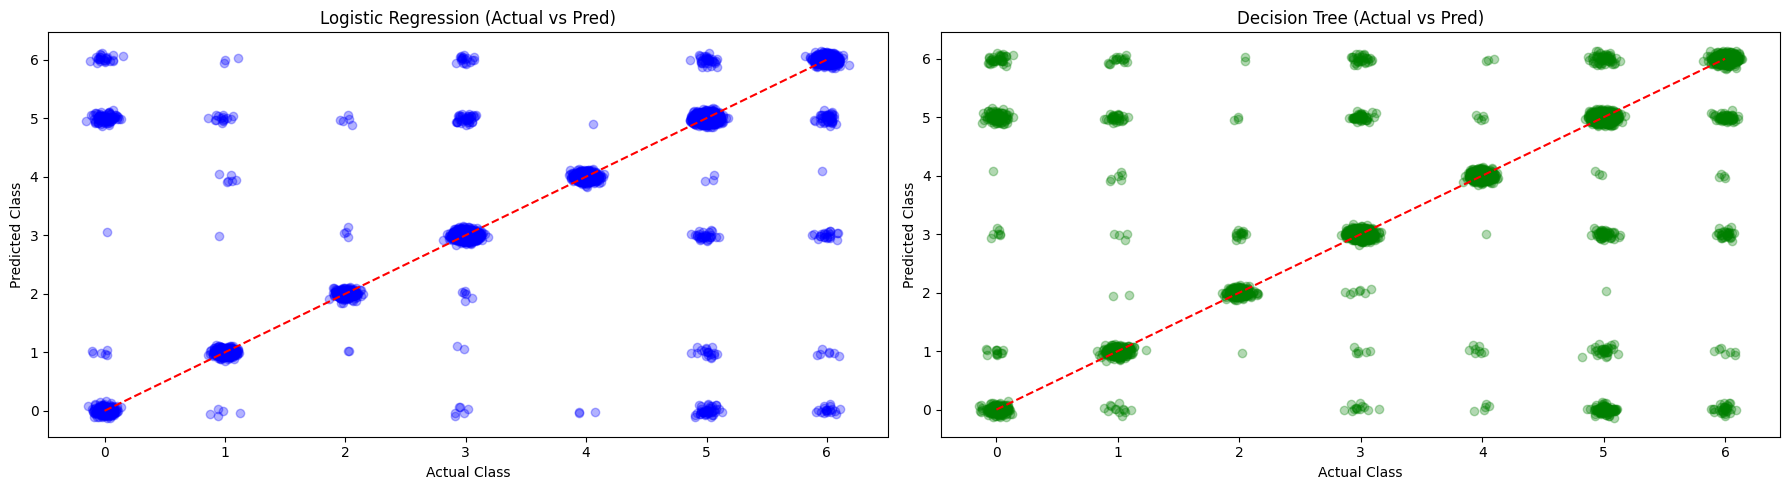

In [62]:
# 7. Visualization: Scatter Plot (with Jitter)
def plot_classification_scatter(y_true, y_pred, title, ax, color):
    # Add small random noise (jitter) to make points visible
    jitter_x = y_true + np.random.normal(0, 0.05, size=len(y_true))
    jitter_y = y_pred + np.random.normal(0, 0.05, size=len(y_pred))

    ax.scatter(jitter_x, jitter_y, alpha=0.3, color=color)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    ax.set_xlabel("Actual Class")
    ax.set_ylabel("Predicted Class")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plot_classification_scatter(y_test, lr_pred, "Logistic Regression (Actual vs Pred)", axes[0], "blue")
plot_classification_scatter(y_test, dt_pred, "Decision Tree (Actual vs Pred)", axes[1], "green")


plt.tight_layout()
plt.show()